#### Verificação das planilhas OT007, OT013 e OT014

Este notebook confere as três planilhas de Orientação Técnica (OT) antes de
consolidá-las, e depois faz a análise de conformidade.

**O ipynb verifica:**
1. Se as 3 planilhas têm o mesmo layout de colunas
2. Valores ausentes / inconsistentes em cada uma
3. Linhas duplicadas
4. Se os 3 campos de status (`CUMPRIDA_TOTALMENTE`, `CUMPRIDA_PARCIALMENTE`, `NAO_CUMPRIDA`) são
   mutuamente exclusivos (cada recomendação só pode ter **um** marcado)
5. Consolidação das 3 em uma única base
6. KPIs finais (geral, por OT, por segmento)


## 1. Importações e carregamento dos arquivos

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 80)

ARQUIVOS = {
    "OT007": "dados\OT007.xlsx",
    "OT013": "dados\OT013.xlsx",
    "OT014": "dados\OT014.xlsx",
}

brutos = {}
for ot, caminho in ARQUIVOS.items():
    df = pd.read_excel(caminho)
    brutos[ot] = df
    print(f"{ot}: {df.shape[0]} linhas x {df.shape[1]} colunas  ->  {caminho}")


OT007: 40 linhas x 9 colunas  ->  dados\OT007.xlsx
OT013: 42 linhas x 9 colunas  ->  dados\OT013.xlsx
OT014: 22 linhas x 9 colunas  ->  dados\OT014.xlsx


In [7]:
# 2. Conferir se tem o mesmo layout

colunas_por_ot = {ot: list(df.columns[:9]) for ot, df in brutos.items()}
for ot, cols in colunas_por_ot.items():
    print(ot, "->", cols)

referencia = colunas_por_ot["OT007"]
iguais = all(cols == referencia for cols in colunas_por_ot.values())
print("\nTodas as planilhas têm as mesmas 9 colunas na mesma ordem?", iguais)

# 3. Limpeza inicial (Cada planilha tem linhas totalmente vazias no final (herdadas do excel original). Removendo essas linhas e manter só as 9 colunas de interesse.)

dfs = {}
for ot, df in brutos.items():
    d = df.iloc[:, :9].copy()
    d = d.dropna(subset=["SEGMENTO"]).reset_index(drop=True)
    d["SEGMENTO"] = d["SEGMENTO"].astype(str).str.strip()
    d["OT"] = ot
    dfs[ot] = d
    print(f"{ot}: {len(d)} linhas úteis (com SEGMENTO preenchido)")


# 4. Valores ausentes por coluna, em cada planilha

for ot, d in dfs.items():
    print(f"--- {ot} ---")
    print(d.isna().sum())
    print()

# 5. Linhas duplicadas

for ot, d in dfs.items():
    dups = d.duplicated(subset=["SEGMENTO", "RECOMENDACAO"], keep=False)
    print(f"{ot}: {dups.sum()} linha(s) duplicada(s)")
    if dups.sum() > 0:
        display(d[dups])

OT007 -> ['SEGMENTO', 'RECOMENDACAO', 'PESSOA_CONTATO', 'DATA_VERIFICACAO_CUMPRIMENTO', 'CUMPRIDA_TOTALMENTE', 'CUMPRIDA_PARCIALMENTE', 'NAO_CUMPRIDA', 'EVIDENCIAS_CUMPRIMENTO', 'OBSERVACOES']
OT013 -> ['SEGMENTO', 'RECOMENDACAO', 'PESSOA_CONTATO', 'DATA_VERIFICACAO_CUMPRIMENTO', 'CUMPRIDA_TOTALMENTE', 'CUMPRIDA_PARCIALMENTE', 'NAO_CUMPRIDA', 'EVIDENCIAS_CUMPRIMENTO', 'OBSERVACOES']
OT014 -> ['SEGMENTO', 'RECOMENDACAO', 'PESSOA_CONTATO', 'DATA_VERIFICACAO_CUMPRIMENTO', 'CUMPRIDA_TOTALMENTE', 'CUMPRIDA_PARCIALMENTE', 'NAO_CUMPRIDA', 'EVIDENCIAS_CUMPRIMENTO', 'OBSERVACOES']

Todas as planilhas têm as mesmas 9 colunas na mesma ordem? True
OT007: 40 linhas úteis (com SEGMENTO preenchido)
OT013: 41 linhas úteis (com SEGMENTO preenchido)
OT014: 22 linhas úteis (com SEGMENTO preenchido)
--- OT007 ---
SEGMENTO                         0
RECOMENDACAO                     0
PESSOA_CONTATO                   0
DATA_VERIFICACAO_CUMPRIMENTO     0
CUMPRIDA_TOTALMENTE              0
CUMPRIDA_PARCIALMENT

#### 6. Consolidação das 3 planilhas em uma base única

In [9]:
ot_titulos = {
    "OT007": "OT007 - Política e Rotinas de Backup",
    "OT013": "OT013 - Segurança da Informação",
    "OT014": "OT014 - Ambiente Físico de TI",
}

def status(row):
    if row["CUMPRIDA_TOTALMENTE"] == True:
        return "Cumprida Totalmente"
    if row["CUMPRIDA_PARCIALMENTE"] == True:
        return "Cumprida Parcialmente"
    if row["NAO_CUMPRIDA"] == True:
        return "Não Cumprida"
    return "Indefinido"

base = pd.concat(dfs.values(), ignore_index=True)
base["OT_TITULO"] = base["OT"].map(ot_titulos)
base["STATUS"] = base.apply(status, axis=1)
base["TEM_EVIDENCIA"] = base["EVIDENCIAS_CUMPRIMENTO"].notna().map({True: "Sim", False: "Não"})

print(f"Base consolidada: {len(base)} linhas")
base.head()


Base consolidada: 103 linhas


,SEGMENTO,RECOMENDACAO,PESSOA_CONTATO,DATA_VERIFICACAO_CUMPRIMENTO,CUMPRIDA_TOTALMENTE,CUMPRIDA_PARCIALMENTE,NAO_CUMPRIDA,EVIDENCIAS_CUMPRIMENTO,OBSERVACOES,OT,OT_TITULO,STATUS,TEM_EVIDENCIA
0,Considerações Gerais sobre Backup,"Definir, documentar e divulgar a política de backup para o Órgão Setorial, e...",Carlos Maciel,2026-08-05,False,False,True,NaN,NaN,OT007,OT007 - Política e Rotinas de Backup,Não Cumprida,Não
1,Considerações Gerais sobre Backup,Explicitar na política de backup as respostas para as quatro questões fundam...,Carlos Maciel,2026-08-05,False,False,True,NaN,NaN,OT007,OT007 - Política e Rotinas de Backup,Não Cumprida,Não
2,Considerações Gerais sobre Backup,A política de backup deve explicitar as datas de frequência para a realizaçã...,Carlos Maciel,2026-08-05,False,False,True,NaN,NaN,OT007,OT007 - Política e Rotinas de Backup,Não Cumprida,Não
3,Considerações Gerais sobre Backup,"Considerar as disponibilidades técnicas, físicas, orçamentárias e de pessoal...",Carlos Maciel,2026-08-05,False,False,True,NaN,Característica desejável à médio prazo,OT007,OT007 - Política e Rotinas de Backup,Não Cumprida,Não
4,Considerações Gerais sobre Backup,"Realizar uma ou mais cópias de segurança para os seguintes dados, no mínimo:...",Carlos Maciel,2026-08-05,False,True,False,As máquinas já possuem diretivas de backup e redundância.,NaN,OT007,OT007 - Política e Rotinas de Backup,Cumprida Parcialmente,Sim


#### 7. Conferência cruzada: soma das partes bate com o total?

In [10]:
contagem_por_ot = base.groupby("OT").size()
print("Linhas por OT na base consolidada:")
print(contagem_por_ot)
print()
print("Confere com o carregamento original (seção 3)?",
      dict(contagem_por_ot) == {ot: len(d) for ot, d in dfs.items()})


Linhas por OT na base consolidada:
OT
OT007    40
OT013    41
OT014    22
dtype: int64

Confere com o carregamento original (seção 3)? True


#### 8. KPIs gerais

In [11]:
total = len(base)
cont = base["STATUS"].value_counts()

print(f"Total de recomendações: {total}")
for status_nome, qtd in cont.items():
    print(f"  {status_nome}: {qtd}  ({qtd/total:.1%})")

indice_cumprimento = (cont.get("Cumprida Totalmente", 0) + cont.get("Cumprida Parcialmente", 0)) / total
print(f"\nÍndice de cumprimento (total + parcial): {indice_cumprimento:.1%}")
print(f"Recomendações com evidência anexada: {(base['TEM_EVIDENCIA'] == 'Sim').sum()}")


Total de recomendações: 103
  Não Cumprida: 41  (39.8%)
  Cumprida Totalmente: 40  (38.8%)
  Cumprida Parcialmente: 19  (18.4%)
  Indefinido: 3  (2.9%)

Índice de cumprimento (total + parcial): 57.3%
Recomendações com evidência anexada: 59


#### 9. Resumo por Orientação Técnica

In [14]:
resumo_ot = (
    base.groupby(["OT", "OT_TITULO"])["STATUS"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=["Cumprida Totalmente", "Cumprida Parcialmente", "Não Cumprida", "Indefinido"], fill_value=0)
)
resumo_ot["Total"] = resumo_ot.sum(axis=1)
resumo_ot["% Cumprimento"] = (resumo_ot["Cumprida Totalmente"] + resumo_ot["Cumprida Parcialmente"]) / resumo_ot["Total"]
resumo_ot["% Cumprimento"] = (resumo_ot["% Cumprimento"] * 100).round(1)
resumo_ot


,STATUS,Cumprida Totalmente,Cumprida Parcialmente,Não Cumprida,Indefinido,Total,% Cumprimento
OT,OT_TITULO,,,,,,
OT007,OT007 - Política e Rotinas de Backup,6,6,26,2,40,30.0
OT013,OT013 - Segurança da Informação,17,9,14,1,41,63.4
OT014,OT014 - Ambiente Físico de TI,17,4,1,0,22,95.5


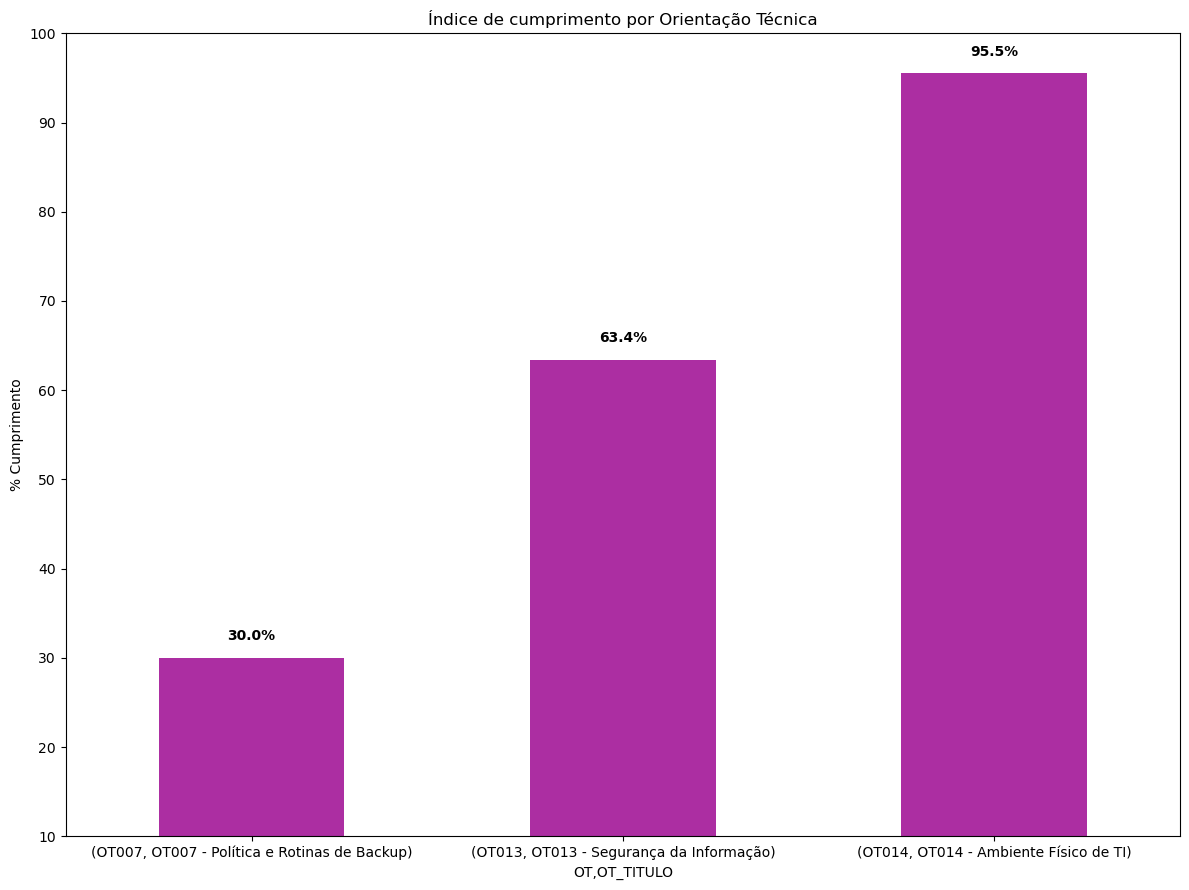

In [21]:
fig, ax = plt.subplots(figsize=(12, 9))
resumo_ot["% Cumprimento"].plot(kind="bar", color="#AC2EA2", ax=ax)
ax.set_ylabel("% Cumprimento")
ax.set_title("Índice de cumprimento por Orientação Técnica")
ax.set_ylim(10, 100)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(resumo_ot["% Cumprimento"]):
    ax.text(i, v + 2, f"{v}%", ha="center", fontweight="bold")
fig.tight_layout()
plt.show()


#### 10. Segmentos mais críticos (mais recomendações não cumpridas)

In [22]:
resumo_seg = (
    base.groupby(["OT", "SEGMENTO"])["STATUS"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=["Cumprida Totalmente", "Cumprida Parcialmente", "Não Cumprida", "Indefinido"], fill_value=0)
    .reset_index()
)
resumo_seg["Total"] = resumo_seg[["Cumprida Totalmente", "Cumprida Parcialmente", "Não Cumprida", "Indefinido"]].sum(axis=1)
resumo_seg["% Cumprimento"] = ((resumo_seg["Cumprida Totalmente"] + resumo_seg["Cumprida Parcialmente"]) / resumo_seg["Total"] * 100).round(1)

top_criticos = resumo_seg.sort_values(["Não Cumprida", "% Cumprimento"], ascending=[False, True]).head(7)
top_criticos[["OT", "SEGMENTO", "Total", "Não Cumprida", "% Cumprimento"]]


STATUS,OT,SEGMENTO,Total,Não Cumprida,% Cumprimento
4,OT007,Locais de Armazenamento e Backup,13,9,23.1
1,OT007,Considerações Gerais sobre Backup,12,9,25.0
6,OT013,Elementos Fundamentais,15,5,60.0
7,OT013,Política em nível zero,21,5,76.2
8,OT013,Políticas básicas,4,4,0.0
5,OT007,"Testes, Retenção e Restauração de Backup",5,4,20.0
3,OT007,Formas e Tipos de Backup,6,4,33.3


#### 11. Exportar a base consolidada e validada

In [26]:
caminho = r"D:\Users\x379975\Documents\Demandas\Indicadores\indicador-apresentacao\saidas\base_consolidada_validada.xlsx"

base.to_excel(caminho, index=False)
print(f"Salvo em {caminho} —", len(base), "linhas.")

Salvo em D:\Users\x379975\Documents\Demandas\Indicadores\indicador-apresentacao\saidas\base_consolidada_validada.xlsx — 103 linhas.
